# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Import Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fatimafarzand/global-petrol-prices-april-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-petrol-prices-april-2026' dataset.
Path to dataset files: /kaggle/input/global-petrol-prices-april-2026


In [ ]:
# Print all of name files
for file in os.listdir(path):
    print(file)

Petrol prices.xlsx
Petrol prices have increased.png
Fuel price.pbix


In [3]:
df = pd.read_excel(path + "/Petrol prices.xlsx")
df.head()

,Country,Region,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent,Price_Trend,Price_Level
0,Hong Kong,Asia,4.11,15.56,3.78,8.7,Stable,Very High
1,Singapore,Asia,3.38,12.79,2.84,19.0,Rising Sharply,Very High
2,Netherlands,Europe,2.80,10.60,2.56,9.4,Stable,Very High
3,Denmark,Europe,2.54,9.61,2.26,12.4,Rising,Very High
4,Germany,Europe,2.47,9.35,2.18,13.3,Rising,Very High


# EDA

Print out all of unique country inside dataset.

In [ ]:
df_unique_country = df['Country'].unique()
print(df_unique_country)

['Hong Kong' 'Singapore' 'Netherlands' 'Denmark' 'Germany' 'Albania'
 'Switzerland' 'France' 'Greece' 'Finland' 'Belgium' 'Austria' 'Italy'
 'Portugal' 'Ireland' 'Estonia' 'United Kingdom' 'New Zealand' 'Australia'
 'Spain' 'Serbia' 'Croatia' 'Hungary' 'Czech Republic' 'Lithuania'
 'Sweden' 'Romania' 'Iceland' 'Poland' 'Bulgaria' 'Montenegro' 'Latvia'
 'Slovakia' 'Bosnia and Herzegovina' 'North Macedonia' 'Slovenia' 'Israel'
 'Japan' 'South Korea' 'China' 'Thailand' 'Philippines' 'Vietnam'
 'Indonesia' 'Malaysia' 'India' 'Pakistan' 'Bangladesh' 'Sri Lanka'
 'Nepal' 'Kazakhstan' 'Azerbaijan' 'Turkmenistan' 'Iran' 'Saudi Arabia'
 'Kuwait' 'UAE' 'Qatar' 'Bahrain' 'Oman' 'Iraq' 'Lebanon' 'Jordan' 'Egypt'
 'United States' 'Canada' 'Mexico' 'Guatemala' 'Costa Rica' 'Honduras'
 'El Salvador' 'Panama' 'Puerto Rico' 'Brazil' 'Argentina' 'Chile'
 'Colombia' 'Peru' 'Bolivia' 'Paraguay' 'Uruguay' 'Venezuela' 'Ecuador'
 'South Africa' 'Nigeria' 'Ghana' 'Kenya' 'Zimbabwe' 'Zambia' 'Tanzania'
 'Ugand

Show unique region, price trend, and price level.

In [ ]:
for col in ['Region','Price_Trend','Price_Level']:
  print(f"Unique {col}: {df[col].unique()}")

Unique Region: ['Asia' 'Europe' 'Oceania' 'Middle East' 'North America' 'South America'
 'Africa' 'Europe/Asia']
Unique Price_Trend: ['Stable' 'Rising Sharply' 'Rising' 'Surging' 'Falling Sharply' 'Falling']
Unique Price_Level: ['Very High' 'High' 'Medium' 'Low' 'Very Low']


In [ ]:
df.describe()

,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent
count,101.000000,101.000000,101.000000,101.000000
mean,1.380891,5.227030,1.278911,8.030693
std,0.709434,2.685499,0.645317,14.363076
min,0.010000,0.040000,0.010000,-65.600000
25%,0.850000,3.220000,0.820000,0.000000
50%,1.310000,4.960000,1.200000,5.300000
75%,1.870000,7.080000,1.720000,12.700000
max,4.110000,15.560000,3.780000,55.100000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               101 non-null    object 
 1   Region                101 non-null    object 
 2   Price_Per_Liter_USD   101 non-null    float64
 3   Price_Per_Gallon_USD  101 non-null    float64
 4   Previous_Price_USD    101 non-null    float64
 5   Price_Change_Percent  101 non-null    float64
 6   Price_Trend           101 non-null    object 
 7   Price_Level           101 non-null    object 
dtypes: float64(4), object(4)
memory usage: 6.4+ KB


In [ ]:
df.isnull().sum()

,0
Country,0
Region,0
Price_Per_Liter_USD,0
Price_Per_Gallon_USD,0
Previous_Price_USD,0
Price_Change_Percent,0
Price_Trend,0
Price_Level,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Visualization

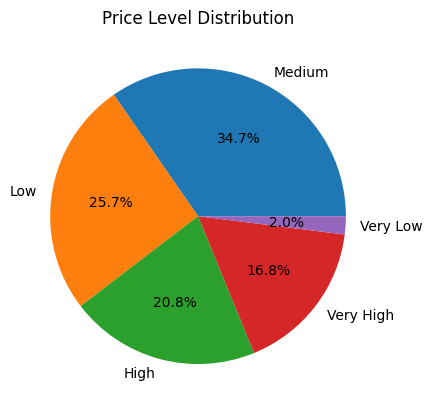

In [ ]:
plt.pie(df['Price_Level'].value_counts(), labels=df['Price_Level'].value_counts().index, autopct='%1.1f%%')
plt.title('Price Level Distribution')
plt.show()

The global petrol price trend has extremely spiking due to oil and gas crisis during the conflict. About 72,3% countries has reached at least medium level of petrol price which directly affected to consumers in any economy sectors.

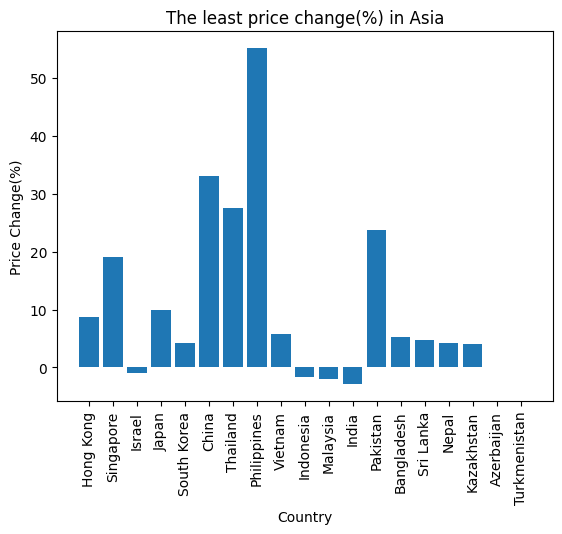

In [5]:
# New dataset only Asia region
df_asia = df[df['Region'] == 'Asia']

# Plot the least price change percent countries in Asia with bar plot
plt.bar(df_asia['Country'], df_asia['Price_Change_Percent'])
plt.xticks(rotation=90)
plt.title('The least price change(%) in Asia')
plt.xlabel('Country')
plt.ylabel('Price Change(%)')
plt.show()

There are 4 countries in Asia which didn't affected by increasing global fuel price. The countries are Israel, Indonesia, Malaysia, and India. Philipines is the most increasing fuel price with is 50% more expensive than their previous fuel price. The increasing fuel price cause some activities must go online.